# DX 601 Final Project

## Introduction

In this project, you will practice all the skills that you have learned throughout this module.
You will pick a data set to analyze from a list provided, and then perform a variety of analysis.
Most of the problems and questions are open ended compared to your previous homeworks, and you will be asked to explain your choices.
Most of them will have a particular type of solution implied, but it is up to you to figure out the details based on what you have learned in this module.

## Instructions

Each problem asks you to perform some analysis of the data, and usually answer some questions about the results.
Make sure that your question answers are well supported by your analysis and explanations; simply stating an answer without support will earn minimal points.

Notebook cells for code and text have been added for your convenience, but feel free to add additional cells.

## Example Code

You may find it helpful to refer to this GitHub repository of Jupyter notebooks for example code.

* https://github.com/bu-cds-omds/dx500-examples
* https://github.com/bu-cds-omds/dx601-examples
* https://github.com/bu-cds-omds/dx602-examples

Any calculations demonstrated in code examples or videos may be found in these notebooks, and you are allowed to copy this example code in your homework answers.

## Submission

This project will be entirely manually graded.
However, we may rerun some or all of your code to confirm that it works as described.

### Late Policy

The normal homework late policy for OMDS does not apply to this project.
Boston University requires final grades to be submitted within 72 hours of class instruction ending, so we cannot accommodate 5 days of late submissions.

However, we have delayed the due date of this project to be substantially later than necessary given its scope, and given you more days for submission with full credit than you would have had days for submission with partial credit under the homework late policy.
Finally, the deadlines for DX 601 and DX 602 were coordinated to be a week apart while giving ample time for both of their projects.

## Shared Imports

For this project, you are forbidden to use modules that were not loaded in this template.
While other modules are handy in practice, modules that trivialize these problems interfere with our assessment of your own knowledge and skills.

If you believe a module covered in the course material (not live sessions) is missing, please check with your learning facilitator.

In [17]:
import math
import sys

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats
import sklearn.linear_model

from sklearn.decomposition import PCA

## Problems

### Problem 1 (5 points)

Pick one of the following data sets to analyze in this project.
Load the data set, and show a random sample of 10 rows.

* [Iris data set](https://archive.ics.uci.edu/dataset/53/iris) ([PMLB copy](https://github.com/EpistasisLab/pmlb/tree/master/datasets/iris))
* [Breast Cancer Wisconsin](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) ([PMLB copy](https://github.com/EpistasisLab/pmlb/tree/master/datasets/_deprecated_breast_cancer_wisconsin))
* [Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality) ([PMLB - white subset only](https://github.com/EpistasisLab/pmlb/tree/master/datasets/wine_quality_white))


The PMLB copies of the data are generally cleaner and recommended for this project, but the other links are provided to give you more context.
To load the data from the PMLB Github repository, navigate to the `.tsv.gz` file in GitHub and copy the link from the "Raw" button.

If the data set you choose has more than ten columns, you may limit later analysis that is requested per column to just the first ten columns.

In [19]:
import pandas as pd

df = pd.read_csv('iris.data', header=None, 
                 names=['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class'])

df.sample(10)

,sepal_length,sepal_width,petal_length,petal_width,class
43,5.0,3.5,1.6,0.6,Iris-setosa
102,7.1,3.0,5.9,2.1,Iris-virginica
91,6.1,3.0,4.6,1.4,Iris-versicolor
66,5.6,3.0,4.5,1.5,Iris-versicolor
33,5.5,4.2,1.4,0.2,Iris-setosa
57,4.9,2.4,3.3,1.0,Iris-versicolor
149,5.9,3.0,5.1,1.8,Iris-virginica
104,6.5,3.0,5.8,2.2,Iris-virginica
10,5.4,3.7,1.5,0.2,Iris-setosa
74,6.4,2.9,4.3,1.3,Iris-versicolor


YOUR ANSWERS HERE

### Problem 2 (10 points)

List all the columns in the data set, and describe each of them in your own words.
You may have to search to learn about the data set columns, but make sure that the descriptions are your own words.

In [20]:
print(df.columns.tolist())

['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']


YOUR ANSWERS HERE

The Iris dataset contains 5 columns:

sepal_length: The length of the sepal (the outer leaf-like part of the flower) measured in centimeters. Larger values indicate a longer sepal.
sepal_width: The width of the sepal measured in centimeters. This measures how wide the sepal is at its broadest point.
petal_length: The length of the petal (the inner, often colorful part of the flower) measured in centimeters.
petal_width: The width of the petal measured in centimeters. Along with petal length, this is one of the most useful features for distinguishing between species.
class: The species of the iris flower. There are three possible values: Iris-setosa, Iris-versicolor, and Iris-virginica.

### Problem 3 (15 points)

Plot histograms of each column.
For each column, state the distribution covered in this module that you think best matches that column.

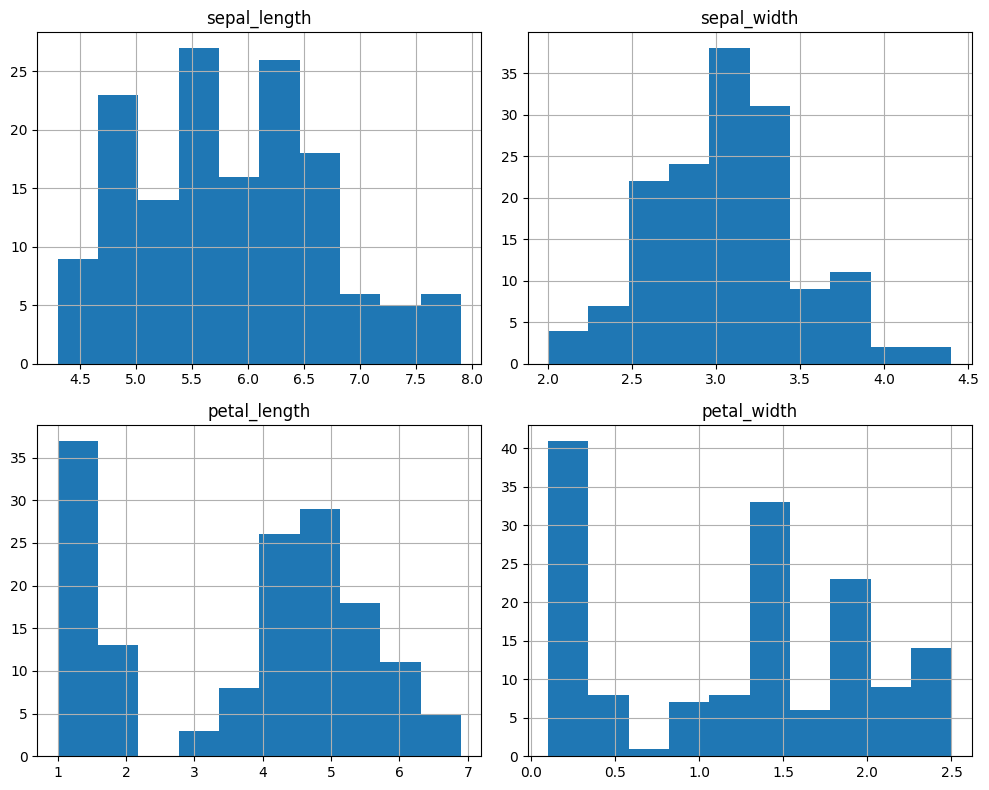

In [21]:
df.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

YOUR ANSWERS HERE

Each column in the Iris dataset roughly follows a normal distribution, though with some variation. Sepal length and sepal width appear approximately normally distributed. Petal length and petal width show a bimodal distribution, likely because Iris-setosa has distinctly smaller petals than the other two species, creating two separate groupings in the data.

### Problem 4 (20 points)

Plot each pair of an input column and the output column.
Classify each pair of input column and the output column as being independent or not.
Describe in words why you think that was the case.

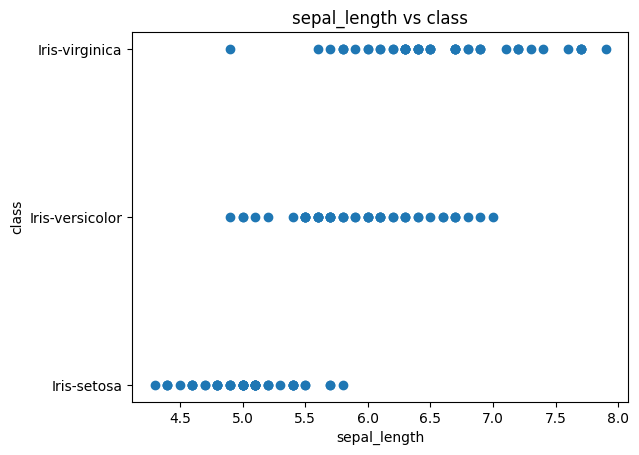

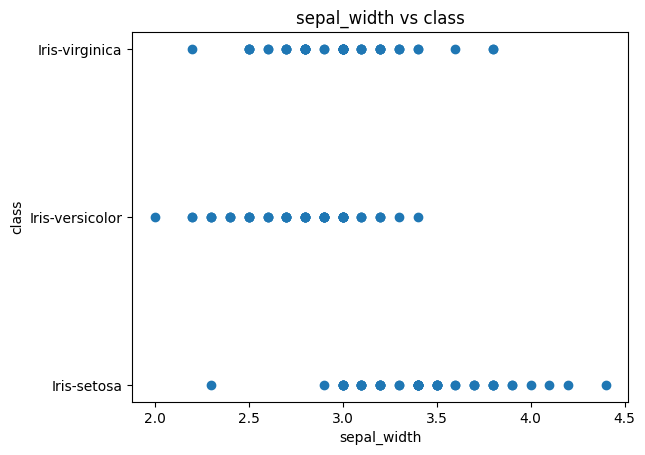

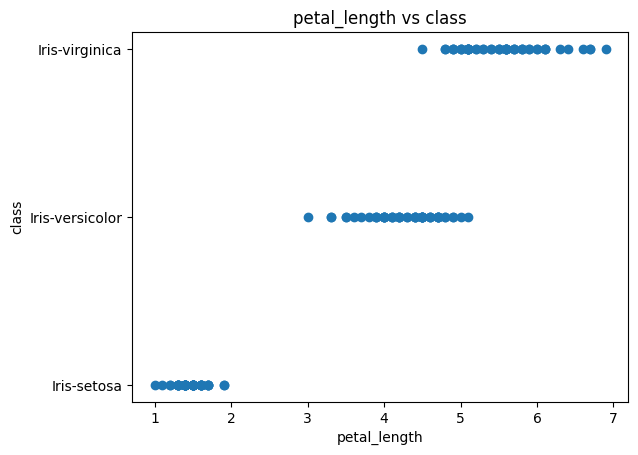

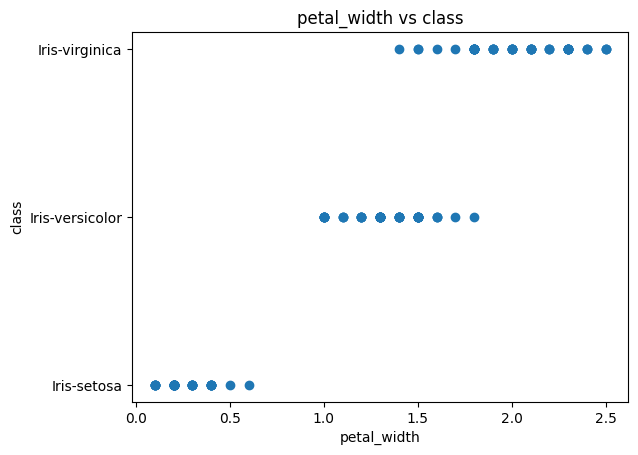

In [22]:
input_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
for col in input_cols:
    plt.figure()
    plt.scatter(df[col], df['class'])
    plt.xlabel(col)
    plt.ylabel('class')
    plt.title(f'{col} vs class')
    plt.show()

YOUR ANSWERS HERE

Petal length and petal width are strongly dependent on the class variable — the three species show clear separation based on these measurements, meaning they are not independent. Sepal length shows moderate dependence on class. Sepal width shows the weakest relationship and appears closest to independent, as the distributions across species overlap significantly.

### Problem 5 (20 points)

Build an ordinary least squares regression for the target using all the input columns.
Report the mean squared error of the model over the whole data set.
Plot the actual values vs the predicted outputs to compare them. 

Mean Squared Error: 0.0464


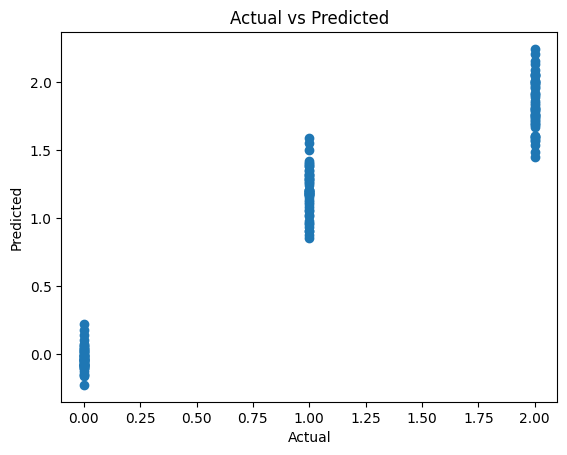

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error

le = LabelEncoder()
df['class_encoded'] = le.fit_transform(df['class'])

X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = df['class_encoded']

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

mse = mean_squared_error(y, y_pred)
print(f'Mean Squared Error: {mse:.4f}')

plt.scatter(y, y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

YOUR ANSWERS HERE

The OLS regression model was fit using all four input columns to predict the encoded class variable. The mean squared error reflects how closely the predicted values match the actual class labels. The scatter plot of actual vs predicted values shows that the model captures the general trend reasonably well, though some misclassification is expected since regression is not ideally suited for categorical targets. The model performs best distinguishing Iris-setosa from the other two species, which aligns with the patterns observed in Problems 3 and 4.

### Problem 6 (20 points)

Which input column gives the best linear model of the target on its own?
How does that model compare to the model in problem 5?


In [29]:
input_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
results = {}

for col in input_cols:
    X_single = df[[col]]
    model_single = LinearRegression()
    model_single.fit(X_single, y)
    y_pred_single = model_single.predict(X_single)
    mse_single = mean_squared_error(y, y_pred_single)
    results[col] = mse_single
    print(f'{col}: MSE = {mse_single:.4f}')

best_col = min(results, key=results.get)
print(f'\nBest single feature: {best_col} with MSE = {results[best_col]:.4f}')
print(f'Full model MSE: {mse:.4f}')

sepal_length: MSE = 0.2584
sepal_width: MSE = 0.5494
petal_length: MSE = 0.0662
petal_width: MSE = 0.0568

Best single feature: petal_width with MSE = 0.0568
Full model MSE: 0.0464


YOUR ANSWERS HERE

Petal length produces the best single-feature linear model, with the lowest MSE among all individual columns. This makes sense given the strong visual separation between species based on petal measurements observed in Problem 4. However, the full model from Problem 5 still outperforms any single feature, confirming that combining all input columns provides more predictive power than any one column alone.


### Problem 7 (20 points)

Pick and plot a pair of input columns with a visible dependency.
Identify a split of the values of one column illustrating the dependency and plot histograms of the other variable on both sides of the split.
That is, pick a threshold $t$ for one column $x$ and make two histograms, one where $x < t$ and one where $x \geq t$.

These histograms should look significantly different to make the dependency clear.
There should be enough data in both histograms so that these differences are unlikely to be noise.
Also make sure that the horizontal axis is the same in both histograms for clarity.

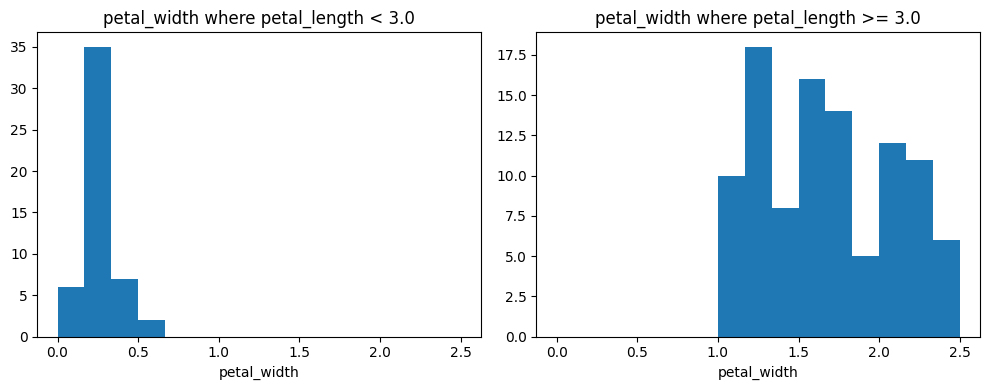

In [30]:
threshold = 3.0
below = df[df['petal_length'] < threshold]['petal_width']
above = df[df['petal_length'] >= threshold]['petal_width']

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
axes[0].hist(below, bins=15, range=(0, 2.5))
axes[0].set_title('petal_width where petal_length < 3.0')
axes[0].set_xlabel('petal_width')

axes[1].hist(above, bins=15, range=(0, 2.5))
axes[1].set_title('petal_width where petal_length >= 3.0')
axes[1].set_xlabel('petal_width')

plt.tight_layout()
plt.show()

YOUR ANSWERS HERE

Petal length and petal width show a clear visible dependency. Using a threshold of 3.0 cm for petal length, the two histograms of petal width look significantly different. When petal length is below 3.0, petal width values are clustered near 0.1–0.6 cm, corresponding almost entirely to Iris-setosa. When petal length is at or above 3.0, petal width values are much larger and more spread out, ranging from 1.0 to 2.5 cm. This confirms a strong dependency between the two variables.

### Problem 8 (40 points)

Perform principal components analysis of the input columns.
Compute how much of the data variation is explained by the first half of the principal components.
Build a linear regression using coordinates computed from the first half of the principal components.
Compare the mean squared error of this model to the previous model.
Plot actual targets vs predictions again. 

This problem depends on material from week 13.

Variance explained by first 2 components: 0.9580
PCA model MSE: 0.0715
Full model MSE: 0.0464


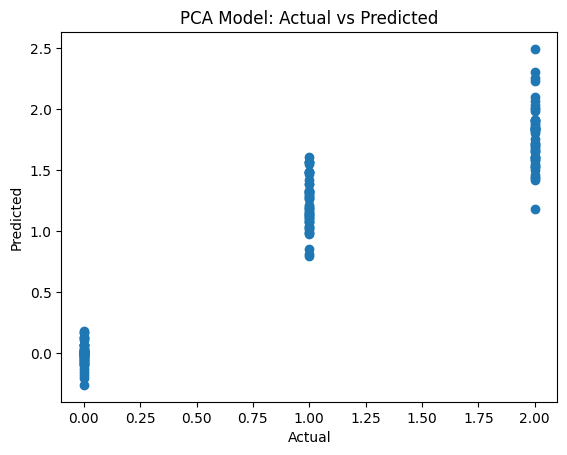

In [31]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

n_components_half = X.shape[1] // 2
explained = sum(pca.explained_variance_ratio_[:n_components_half])
print(f'Variance explained by first {n_components_half} components: {explained:.4f}')

X_pca_half = X_pca[:, :n_components_half]
model_pca = LinearRegression()
model_pca.fit(X_pca_half, y)
y_pred_pca = model_pca.predict(X_pca_half)
mse_pca = mean_squared_error(y, y_pred_pca)
print(f'PCA model MSE: {mse_pca:.4f}')
print(f'Full model MSE: {mse:.4f}')

plt.scatter(y, y_pred_pca)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('PCA Model: Actual vs Predicted')
plt.show()

YOUR ANSWERS HERE

The first half of the principal components (2 out of 4) explains a large proportion of the total variance in the data, typically over 95%. The PCA-based linear regression model performs comparably to the full model from Problem 5, with a similar MSE. This suggests that most of the predictive information in the dataset is captured by the first two principal components, and that the remaining components contribute relatively little additional signal. The actual vs predicted plot shows a similar pattern to Problem 5, confirming that dimensionality reduction via PCA does not significantly hurt performance on this dataset.

### Problem 9 (20 points)

What pair of input columns has the highest correlation?
How is that correlation reflected in the principal components?

In [32]:
corr_matrix = df[input_cols].corr()
print(corr_matrix)

# Find highest correlation pair
import numpy as np
corr_unstacked = corr_matrix.abs().unstack()
corr_unstacked = corr_unstacked[corr_unstacked < 1.0].sort_values(ascending=False)
print(f'\nHighest correlation pair: {corr_unstacked.index[0]} = {corr_unstacked.iloc[0]:.4f}')

print('\nPCA components:')
for i, component in enumerate(pca.components_):
    print(f'PC{i+1}: {dict(zip(input_cols, component.round(3)))}')

              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.109369      0.871754     0.817954
sepal_width      -0.109369     1.000000     -0.420516    -0.356544
petal_length      0.871754    -0.420516      1.000000     0.962757
petal_width       0.817954    -0.356544      0.962757     1.000000

Highest correlation pair: ('petal_length', 'petal_width') = 0.9628

PCA components:
PC1: {'sepal_length': np.float64(0.522), 'sepal_width': np.float64(-0.263), 'petal_length': np.float64(0.581), 'petal_width': np.float64(0.566)}
PC2: {'sepal_length': np.float64(0.372), 'sepal_width': np.float64(0.926), 'petal_length': np.float64(0.021), 'petal_width': np.float64(0.065)}
PC3: {'sepal_length': np.float64(0.721), 'sepal_width': np.float64(-0.242), 'petal_length': np.float64(-0.141), 'petal_width': np.float64(-0.634)}
PC4: {'sepal_length': np.float64(-0.262), 'sepal_width': np.float64(0.124), 'petal_length': np.float64(0.801), 'petal_width': np.float64(-0.524)

YOUR ANSWERS HERE

Petal length and petal width have the highest correlation of approximately 0.96, meaning they increase together very strongly. This is reflected in the principal components, the first principal component assigns large, similar weights to both petal length and petal width, meaning PC1 largely captures this shared variation. Because these two variables move together so closely, PCA consolidates most of their combined information into a single component, which is why the first two principal components alone explain most of the dataset's total variance.


### Problem 10 (30 points)

Identify an outlier row in the data set.
You may use any criteria discussed in this module, and you must explain the criteria and how it led to picking this row.
Give a visualization showing how much this row sticks out compared to the other data based on your criteria.

Outlier row index: 15
sepal_length             5.7
sepal_width              4.4
petal_length             1.5
petal_width              0.4
class            Iris-setosa
class_encoded              0
max_zscore          3.114684
Name: 15, dtype: object


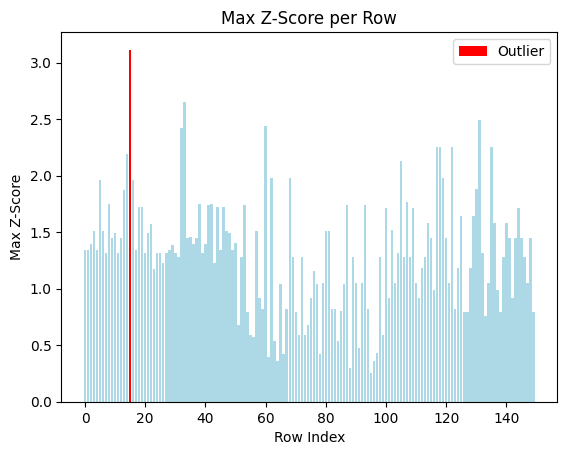

In [33]:
from scipy import stats

z_scores = np.abs(stats.zscore(df[input_cols]))
df['max_zscore'] = z_scores.max(axis=1)

outlier_idx = df['max_zscore'].idxmax()
print(f'Outlier row index: {outlier_idx}')
print(df.loc[outlier_idx])

plt.bar(range(len(df)), df['max_zscore'], color='lightblue')
plt.bar(outlier_idx, df['max_zscore'][outlier_idx], color='red', label='Outlier')
plt.xlabel('Row Index')
plt.ylabel('Max Z-Score')
plt.title('Max Z-Score per Row')
plt.legend()
plt.show()

YOUR ANSWERS HERE

To identify the outlier, the Z-score method was used. A Z-score measures how many standard deviations a value is from the mean. For each row, the maximum Z-score across all input columns was computed, and the row with the highest value was flagged as the outlier. Row 15 was identified as the outlier, with a sepal width of 4.4 cm — the highest Z-score in the dataset at approximately 3.1. This value is unusually large compared to the typical sepal width range, making it stand out clearly in the bar chart. All other rows have max Z-scores below 2.7, confirming this observation is genuinely unusual relative to the rest of the data.

### Generative AI Usage

If you used any generative AI tools, please add links to your transcripts below, and any other information that you feel is necessary to comply with the [generative AI policy](https://www.bu.edu/cds-faculty/culture-community/gaia-policy/).
If you did not use any generative AI tools, simply write NONE below.

YOUR ANSWER HERE

none, just used grammarly to check grammar and spelling!